In [23]:
import pandas as pd

# Population Analysis
Reading and merging the scraped country and region data.

In [51]:
countries = pd.read_csv("countries.csv")
regions = pd.read_csv("regions.csv")
countries.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%


Checking whether any country names fail to match between the two CSVs before we merge them 

In [52]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

{'Brunei',
 'Czech Republic (Czechia)',
 'Hong Kong',
 'Macao',
 'North Macedonia',
 'Saint Barthelemy',
 'Saint Kitts & Nevis',
 'Saint Pierre & Miquelon',
 'Sao Tome & Principe',
 'St. Vincent & Grenadines',
 'Turks and Caicos',
 'U.S. Virgin Islands',
 'Wallis & Futuna'}

Rename and merge

In [53]:
renames = {"Czech Republic (Czechia)": "Czechia",
    "Hong Kong": "China, Hong Kong SAR",
    "Macao": "China, Macao SAR",
    "North Macedonia": "Republic of North Macedonia",
    "Brunei": "Brunei Darussalam",
    "Saint Barthelemy": "Saint Barthélemy",
    "Saint Kitts & Nevis": "Saint Kitts and Nevis",
    "Saint Pierre & Miquelon": "Saint Pierre and Miquelon",
    "Sao Tome & Principe": "Sao Tome and Principe",
    "St. Vincent & Grenadines": "Saint Vincent and the Grenadines",
    "Turks and Caicos": "Turks and Caicos Islands",
    "U.S. Virgin Islands": "United States Virgin Islands",
    "Wallis & Futuna": "Wallis and Futuna Islands",
  }
for old_name, new_name in renames.items():
    countries.loc[countries["country"] == old_name, "country"] = new_name

Check: returns set() if everything is good

In [54]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

set()

# merge

In [55]:
data = pd.merge(countries, regions, on="country")
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%,Asia
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%,Asia
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%,Northern America
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%,Asia
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%,Asia


Clean - commas, percent signs, or theminus sign. Converting to real numbers so we can do math

In [56]:
def clean_number(text):
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.replace("−", "-")
    text = text.replace("–", "nan")
    return text
  
  
data["population"] = [int(clean_number(value)) for value in data["population"]]
data["yearly_change"] = [float(clean_number(value)) for value in data["yearly_change"]]
data["net_change"] = [int(clean_number(value)) for value in data["net_change"]]
data["land_area"] = [int(clean_number(value)) for value in data["land_area"]]
data["migrants"] = [int(clean_number(value)) for value in data["migrants"]]
data["urban_pop"] = [float(clean_number(value)) for value in data["urban_pop"]]
data["world_share"] = [float(clean_number(value)) for value in data["world_share"]]
data["density"] = [int(clean_number(value)) for value in data["density"]]
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,1476625576,0.87,12760051,497,2973190,-440456,1.93,29.2,37.6,17.8,Asia
1,2,China,1412914089,-0.22,-3182005,150,9388211,-232107,1.03,40.6,68.7,17.0,Asia
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.2,Northern America
3,4,Indonesia,287886782,0.76,2165546,159,1811570,-39472,2.08,30.7,60.3,3.5,Asia
4,5,Pakistan,259299791,1.60,4080237,336,770880,-1144738,3.44,20.8,34.7,3.1,Asia


In [60]:
continent_averages = data.groupby("continent")[["density", "fertility_rate", "median_age", "urban_pop"]].mean()
continent_averages

,density,fertility_rate,median_age,urban_pop
continent,,,,
Africa,136.965517,3.591897,21.846552,49.764912
Asia,1055.843137,2.057843,31.323529,60.545833
Europe,813.510638,1.461277,43.334043,72.013636
Latin America and the Caribbean,200.560000,1.738800,35.168000,65.673171
Northern America,271.000000,1.512000,41.800000,86.875000
Oceania,130.391304,2.508696,29.147826,55.425000


In [61]:
for column in ["density", "fertility_rate", "median_age", "urban_pop"]:
    top = continent_averages.sort_values(column, ascending=False).head(1)
    print(column)
    print(top)

density
               density  fertility_rate  median_age  urban_pop
continent                                                    
Asia       1055.843137        2.057843   31.323529  60.545833
fertility_rate
              density  fertility_rate  median_age  urban_pop
continent                                                   
Africa     136.965517        3.591897   21.846552  49.764912
median_age
              density  fertility_rate  median_age  urban_pop
continent                                                   
Europe     813.510638        1.461277   43.334043  72.013636
urban_pop
                  density  fertility_rate  median_age  urban_pop
continent                                                       
Northern America    271.0           1.512        41.8     86.875


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='continent'>

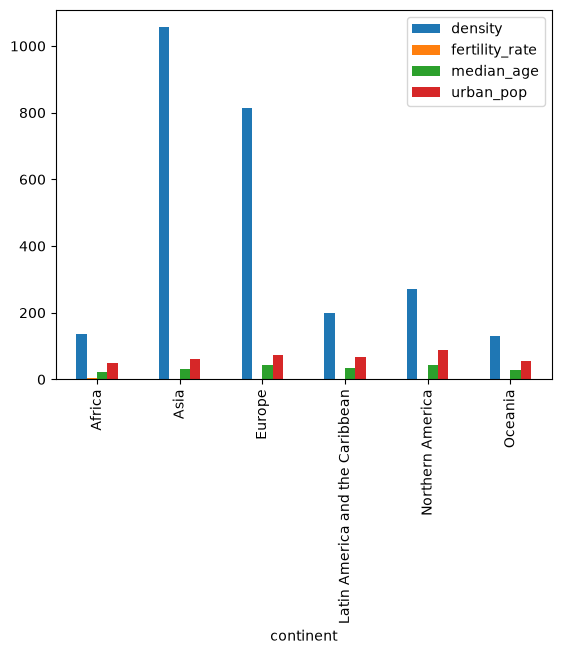

In [63]:
continent_averages.plot.bar()

<Axes: xlabel='fertility_rate', ylabel='median_age'>

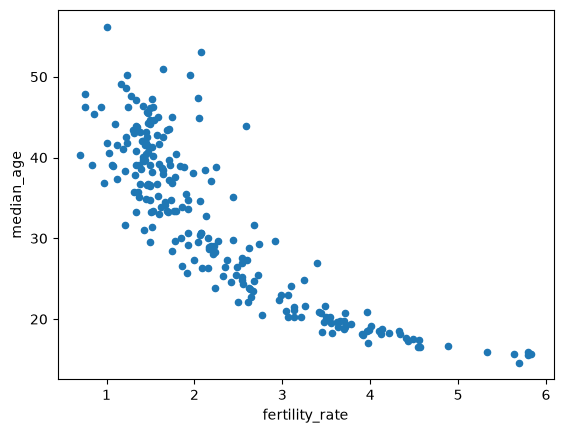

In [64]:
data.plot.scatter(x="fertility_rate", y="median_age")

In [65]:
data.sort_values("density", ascending=False)[["country", "density"]].head(10)

,country,density
215,Monaco,25562
166,"China, Macao SAR",24106
114,Singapore,8437
106,"China, Hong Kong SAR",7027
212,Gibraltar,4087
152,Bahrain,2205
172,Maldives,1772
171,Malta,1716
7,Bangladesh,1366
210,Sint Maarten,1307


In [66]:
data.sort_values("density")[["country", "density"]].head(10)

,country,density
206,Greenland,0
230,Falkland Islands,0
170,Western Sahara,2
132,Mongolia,2
54,Australia,4
37,Canada,4
104,Libya,4
177,Iceland,4
136,Namibia,4
164,Guyana,4


In [67]:
data.sort_values("urban_pop", ascending=False)[["country", "urban_pop"]].head(10)

,country,urban_pop
210,Sint Maarten,99.6
82,Belgium,99.0
190,Guam,98.9
166,"China, Macao SAR",98.3
170,Western Sahara,97.6
34,Argentina,96.5
135,Qatar,96.2
182,French Guiana,95.2
223,Nauru,93.8
11,Japan,93.4


In [68]:
data.sort_values("urban_pop")[["country", "urban_pop"]].head(10)

,country,urban_pop
229,Montserrat,11.7
88,Papua New Guinea,12.7
213,Liechtenstein,14.8
77,Burundi,15.4
187,Samoa,16.3
59,Sri Lanka,18.2
76,Rwanda,18.5
52,Niger,18.5
189,Saint Lucia,20.1
61,Malawi,20.2


In [69]:
data.sort_values("net_change", ascending=False)[["country", "net_change"]].head(10)

,country,net_change
0,India,12760051
5,Nigeria,4904050
4,Pakistan,4080237
14,DR Congo,3619689
9,Ethiopia,3430134
3,Indonesia,2165546
7,Bangladesh,2131145
19,Tanzania,2017915
2,United States,1759687
12,Egypt,1735180


In [70]:
data.sort_values("net_change")[["country", "net_change"]].head(10)

,country,net_change
1,China,-3182005
11,Japan,-675748
8,Russia,-602935
18,Germany,-430817
41,Poland,-297722
24,Italy,-220094
69,Romania,-108045
60,Taiwan,-101501
91,Czechia,-81458
30,South Korea,-66641


In [72]:
continent_share = data.groupby("continent")["world_share"].sum()
continent_share

continent
Africa                             19.042662
Asia                               58.550500
Europe                              8.931726
Latin America and the Caribbean     8.119064
Northern America                    4.691516
Oceania                             0.562494
Name: world_share, dtype: float64

<Axes: xlabel='continent'>

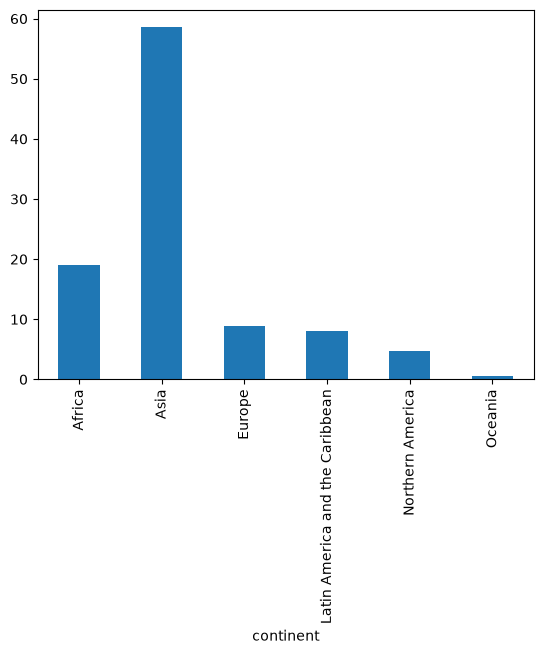

In [73]:
continent_share.plot.bar()

<Axes: xlabel='land_area', ylabel='population'>

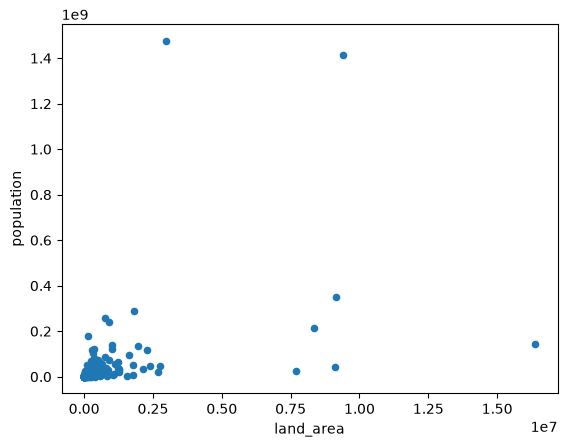

In [74]:
data.plot.scatter(x="land_area", y="population")

In [75]:
world_density = data["population"].sum() / data["land_area"].sum()
data["expected_population"] = data["land_area"] * world_density
data["size_population_ratio"] = data["population"] / data["expected_population"]
data[["country", "land_area", "population", "size_population_ratio"]].head()

,country,land_area,population,size_population_ratio
0,India,2973190,1476625576,7.785511
1,China,9388211,1412914089,2.359241
2,United States,9147420,349035494,0.598150
3,Indonesia,1811570,287886782,2.491185
4,Pakistan,770880,259299791,5.272964


In [76]:
data.sort_values("size_population_ratio", ascending=False)[["country", "land_area", "population", "size_population_ratio"]].head(10)

,country,land_area,population,size_population_ratio
233,Holy See,0,506,inf
215,Monaco,1,38087,597.057480
166,"China, Macao SAR",30,723188,377.893424
114,Singapore,700,5905748,132.256264
106,"China, Hong Kong SAR",1050,7378602,110.160060
212,Gibraltar,10,40867,64.063717
152,Bahrain,760,1675572,34.561205
172,Maldives,300,531517,27.773799
171,Malta,320,549011,26.894932
7,Bangladesh,130170,177818044,21.414321


In [77]:
data.sort_values("size_population_ratio")[["country", "land_area", "population", "size_population_ratio"]].head(10)

,country,land_area,population,size_population_ratio
206,Greenland,410450,55629,0.002125
230,Falkland Islands,12170,3465,0.004463
132,Mongolia,1553560,3556798,0.035890
170,Western Sahara,266000,610813,0.035997
54,Australia,7682300,27227096,0.055558
136,Namibia,823290,3153246,0.060041
182,French Guiana,82200,318872,0.060811
177,Iceland,100250,402329,0.062912
168,Suriname,156000,645256,0.064841
164,Guyana,196850,840890,0.066964
